# B-Spline Fitting on Motion Trajectory

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.interpolate import make_lsq_spline

from src.viz import Plotter, AnimatedPlotter

## Load Clip

In [ ]:
CLIP_IDX = 20
JOINT_NAME = "rightIndexTip"

# 72 20 circling
# 0 messy
# 16 line segments
# 42 swirl

In [18]:
data = np.load(f"data/tensorclip/tclip_{CLIP_IDX}.npz", allow_pickle=True)
clip = data["clip"].item()
traj = clip[JOINT_NAME][:, :3]

plotter = Plotter(
    title=f"Trajectory of {JOINT_NAME}", template="seaborn", 
    width=800, height=600, 
    margin={"t": 80, "b": 10, "l": 10, "r": 10},
    scene={"aspectmode": "cube"},
    scene_camera={"up": {"x": 0, "y": 1, "z": 0}}
    )
plotter.add_trajectory(traj, color="blue", opacity=.5)
plotter.add_points(traj, color="blue", point_size=3, opacity=.5)
plotter.show()

## B-Spline Least Square Approzimation

In [19]:
DEGREE = 2
N_FRAMES = traj.shape[0]
N_CPS = int(N_FRAMES / 16)
N_KNOTS = DEGREE + N_CPS - 1

print(f"num frames       = {N_FRAMES}")
print(f"num control pts. = {N_CPS}")
print(f"num knots        = {N_KNOTS}")

num frames       = 721
num control pts. = 45
num knots        = 46


In [20]:
def generate_open_knots(degree, num_cps):
    if num_cps < degree + 1:
        raise ValueError(f"num_cps have to be >= degree + 1, got degree={degree} and num_cps={num_cps}")
    
    num_interior = num_cps - degree - 1

    head = np.repeat(0, degree + 1)
    tail = np.repeat(1, degree + 1)
    interior = np.linspace(0, 1, num_interior + 2)[1:-1]

    return np.concatenate([head, interior, tail])

In [21]:
def generate_arc_length_params(pts):
    diffs = np.diff(pts, axis=0)
    step_dists = np.linalg.norm(diffs, axis=1)
    cumu_dists = np.cumsum(step_dists)
    cumu_dists = np.concatenate(([0], cumu_dists))
    return cumu_dists / cumu_dists[-1]

def generate_params(pts, power=0.5):    # power=1 arc-length, 0.5 centripetal, 0 uniform
    seg = np.linalg.norm(np.diff(pts, axis=0), axis=1) ** power
    d = np.concatenate(([0], np.cumsum(seg)))
    return d / d[-1]

In [22]:
u = generate_params(traj, power=.5)
knots = generate_open_knots(DEGREE, N_CPS)

lsq_spl = make_lsq_spline(u, traj, knots, DEGREE)
approx_traj = lsq_spl(u)

plotter.clear()

plotter.add_trajectory(traj, color="blue", opacity=.5, name="ground truth tarj.")
plotter.add_points(traj, color="blue", point_size=3, opacity=.5, text=[f"frame {f}" for f in range(N_FRAMES)] ,name="ground truth keyframes")

plotter.add_trajectory(approx_traj, color="red", opacity=.5, name="approx. tarj.")
plotter.add_points(approx_traj, color="red", point_size=3, opacity=.5, text=[f"frame {f}" for f in range(N_FRAMES)], name="approx. keyframes")

plotter.show()

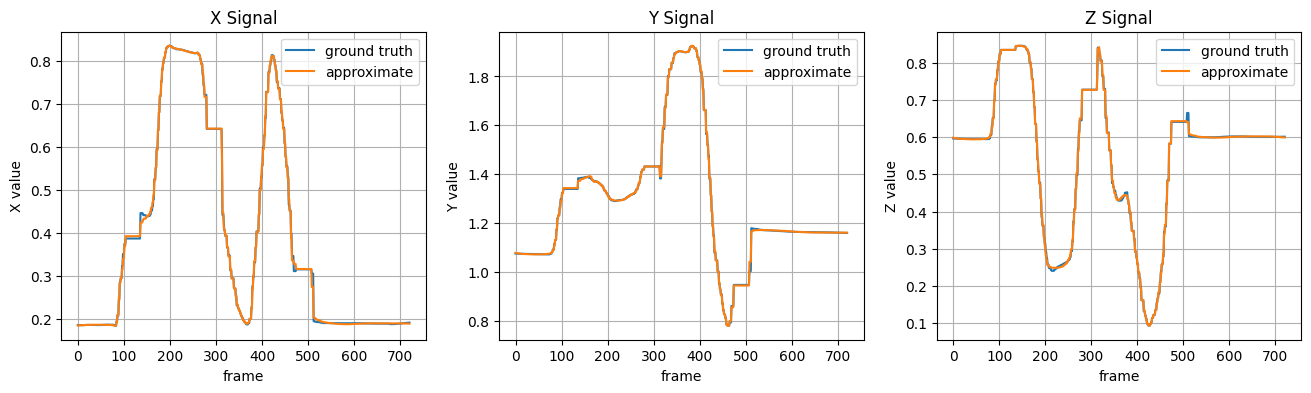

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
axes_label=["X", "Y", "Z"]

for i, ax in enumerate(axs):
    ax.plot(traj[:,i], label="ground truth")
    ax.plot(approx_traj[:,i], label="approximate")
    ax.set_title(f"{axes_label[i]} Signal")
    ax.set_xlabel("frame")
    ax.set_ylabel(f"{axes_label[i]} value")
    ax.legend()
    ax.grid()

plt.show()

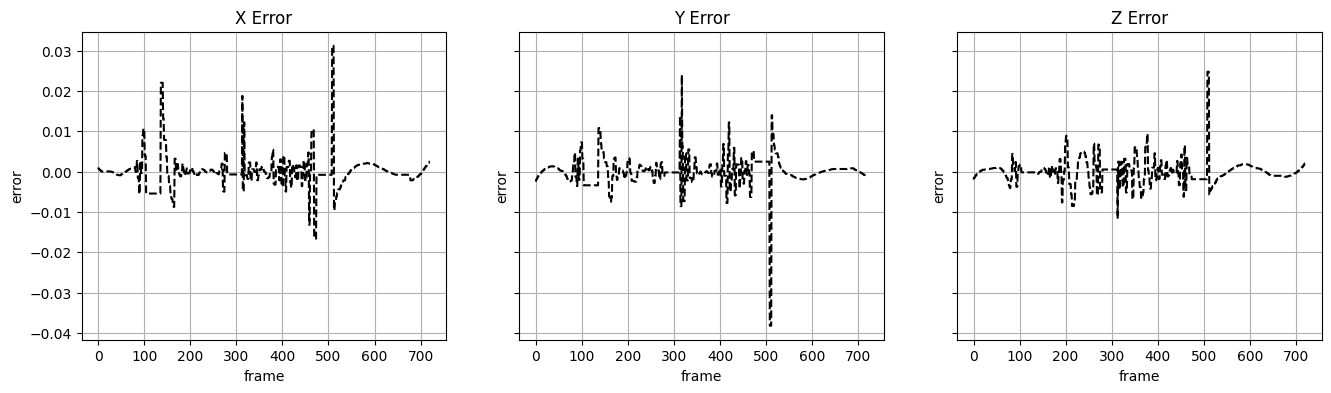

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)
axes_label=["X", "Y", "Z"]

for i, ax in enumerate(axs):
    ax.plot(traj[:,i] - approx_traj[:,i], 'k--')
    ax.set_title(f"{axes_label[i]} Error")
    ax.set_xlabel("frame")
    ax.set_ylabel("error")
    ax.grid()

plt.show()

In [25]:
errs = np.linalg.norm(traj - approx_traj, axis=1)
sq_errs = errs ** 2
mse = sq_errs.mean()

print(f"mse={mse}")

mse=4.710836079294982e-05


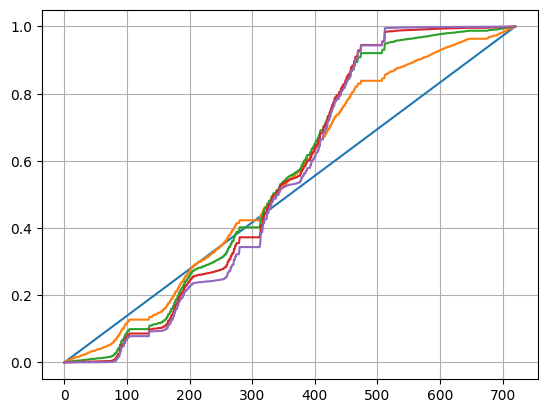

In [26]:
for p in np.linspace(0, 1, 5):
    plt.plot(generate_params(traj, power=p), label=p)

plt.grid()
plt.show()

In [27]:
print("near-still frames (≈zero step):", int((np.diff(u) < 1e-6).sum()))
print("how many frames pile at the end:", int((u > 0.999).sum()), "/", len(u))

edges = np.r_[0, knots[DEGREE+1:-(DEGREE+1)], 1]      # interior knot spans
print("data points per knot span:", np.histogram(u, bins=edges)[0])

near-still frames (≈zero step): 481
how many frames pile at the end: 4 / 721
data points per knot span: [ 81   8   7   5  49  16   8   4   7   7   7  13  31  16   7   7   7  34
   4   6   7   8   9  16  15   7   9   7   5   7   5   7   4   9   5   7
   7   7   4  39  13  79 121]


In [28]:
ap = AnimatedPlotter(
    title="GT vs approx", 
    width=800, height=600, 
    margin={"t": 80, "b": 10, "l": 10, "r": 10},
    scene={"aspectmode": "cube"},
    scene_camera={"up": {"x": 0, "y": 1, "z": 0}},
    fps=30, stride=4
    )
ap = ap.add_trajectory(traj, name="ground truth", color="blue", trail_length=40, show_path=False)
ap = ap.add_trajectory(approx_traj, name="approx", color="red", trail_length=40, show_path=False)
ap.show()